## Experiment 1 — Weight Recovery: 3-Point Stencil (2nd Order)
Proof that we should get the same as the FD stencil if we use the following matrix inversion:
$$
\begin{bmatrix}
1 & 1  & 1 \\
\Delta x_1 & \Delta x_2  & \Delta x_3 \\
\alpha \Delta t_1 + \tfrac{1}{2}\Delta x_1^2 & \alpha \Delta t_2 + \tfrac{1}{2}\Delta x_2^2 &  \alpha \Delta t_n + \tfrac{1}{2}\Delta x_3^2
\end{bmatrix}
\begin{bmatrix} w_1 \\ w_2  \\ w_3 \end{bmatrix}
=
\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}
$$

$$
u^* = \sum_{i=1}^{n} w_i \, u_i
$$
### Constraint System $Aw = b$
Three rows are imposed:
1. weights sum to 1
2. eliminates first-order spatial error
3. substitutes $u_t = \alpha u_{xx}$ via the combined row
   $\alpha \Delta t_i + \tfrac{1}{2}\Delta x_i^2$

In [31]:
import numpy as np

# Parameters
alpha = 0.1
nx = 20
nt = 100
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

r = 0.04  # CFL number
dt = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.6f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha * dt / dx**2:.4f}")

# Pick one target point: interior, second time step
# target: (x*, t*) = (x[5], t[1])
j_star = 5
k_star = 1

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget point: x* = {x_star:.4f}, t* = {t_star:.6f}")

# 3 neighbours (all at previous time step k=0)
# n1: centre  (x*,       t* - dt)
# n2: left    (x* - dx,  t* - dt)
# n3: right   (x* + dx,  t* - dt)
dx_nb = np.array([0.0, -dx, dx])
dt_nb = np.array([-dt, -dt, -dt])

print("\nNeighbours (relative offsets):")
print(f"  Centre: dx = {dx_nb[0]:.4f}, dt = {dt_nb[0]:.6f}")
print(f"  Left:   dx = {dx_nb[1]:.4f}, dt = {dt_nb[1]:.6f}")
print(f"  Right:  dx = {dx_nb[2]:.4f}, dt = {dt_nb[2]:.6f}")

# Build 3x3 matrix A and solve
# Row 1: consistency   sum(w) = 1
# Row 2: spatial bias  sum(w*dx) = 0
# Row 3: diffusion     sum(w*(alpha*dt + 0.5*dx^2)) = 0
A = np.array([
    [1.0, 1.0, 1.0],
    dx_nb,
    alpha * dt_nb + 0.5 * dx_nb**2
])
b = np.array([1.0, 0.0, 0.0])

print("\nMatrix A:")
print(A)
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# FD weights (explicit Euler)
# u* = (1 - 2r)*u_c + r*u_l + r*u_r
w_fd = np.array([1 - 2 * r, r, r])

print("\nWeight Comparison")
print(f"{'':10s} {'Centre':>12} {'Left':>12} {'Right':>12}")
print(f"{'Our w':10s} {w[0]:>12.8f} {w[1]:>12.8f} {w[2]:>12.8f}")
print(f"{'FD w':10s} {w_fd[0]:>12.8f} {w_fd[1]:>12.8f} {w_fd[2]:>12.8f}")
print(f"{'Diff':10s} {w[0] - w_fd[0]:>12.2e} {w[1] - w_fd[1]:>12.2e} {w[2] - w_fd[2]:>12.2e}")

# Apply weights to reconstruct u at target
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star, t_star - dt),
    u_true(x_star - dx, t_star - dt),
    u_true(x_star + dx, t_star - dt),
])

u_pred = w @ u_nb
u_fd = w_fd @ u_nb
u_exact = u_true(x_star, t_star)
print("\n" + "="*55)
print("NEIGHBOUR OFFSETS (relative)")
print("="*55)
print(f"{'Point':<10}{'dx':>12}{'dt':>15}")
print("-"*37)
print(f"{'Centre':<10}{dx_nb[0]:>12.4f}{dt_nb[0]:>15.6f}")
print(f"{'Left':<10}{dx_nb[1]:>12.4f}{dt_nb[1]:>15.6f}")
print(f"{'Right':<10}{dx_nb[2]:>12.4f}{dt_nb[2]:>15.6f}")

print("\n" + "="*55)
print("WEIGHT COMPARISON")
print("="*55)
print(f"{'':<10}{'Centre':>14}{'Left':>14}{'Right':>14}")
print("-"*52)
print(f"{'Our':<10}{w[0]:>14.8f}{w[1]:>14.8f}{w[2]:>14.8f}")
print(f"{'FD':<10}{w_fd[0]:>14.8f}{w_fd[1]:>14.8f}{w_fd[2]:>14.8f}")
print(f"{'Diff':<10}{(w[0]-w_fd[0]):>14.2e}{(w[1]-w_fd[1]):>14.2e}{(w[2]-w_fd[2]):>14.2e}")

print("\n" + "="*55)
print("RECONSTRUCTION AT TARGET")
print("="*55)
print(f"Predicted (our weights) : {u_pred:.8f}")
print(f"Predicted (FD weights)  : {u_fd:.8f}")
print(f"Exact solution          : {u_exact:.8f}")

print("\nErrors")
print("-"*20)
print(f"Our vs Exact            : {abs(u_pred - u_exact):.4e}")
print(f"FD  vs Exact            : {abs(u_fd - u_exact):.4e}")
print(f"Our vs FD               : {abs(u_pred - u_fd):.4e}")
print("="*55)

dx = 0.052632
dt = 0.001108
CFL r = alpha*dt/dx^2 = 0.0400

Target point: x* = 0.2632, t* = 0.001108

Neighbours (relative offsets):
  Centre: dx = 0.0000, dt = -0.001108
  Left:   dx = -0.0526, dt = -0.001108
  Right:  dx = 0.0526, dt = -0.001108

Matrix A:
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -5.26315789e-02  5.26315789e-02]
 [-1.10803324e-04  1.27423823e-03  1.27423823e-03]]

b = [1. 0. 0.]

Weight Comparison
                 Centre         Left        Right
Our w        0.92000000   0.04000000   0.04000000
FD w         0.92000000   0.04000000   0.04000000
Diff          -1.11e-16    -6.94e-18    -6.94e-18

NEIGHBOUR OFFSETS (relative)
Point               dx             dt
-------------------------------------
Centre          0.0000      -0.001108
Left           -0.0526      -0.001108
Right           0.0526      -0.001108

WEIGHT COMPARISON
                  Centre          Left         Right
----------------------------------------------------
Our    

## Experiment 2 — Full Rollout: 3-Point Stencil (2nd Order)

**Setup:** $u_t = \alpha u_{xx}$, $\alpha = 0.1$, CFL $r = 0.4$, $T = 1.097$, uniform grid.
3 neighbours, 3 constraints (consistency + kill $u_x$ + PDE).
 
Method is **algebraically identical** to explicit Euler FD at this stencil size.

dx = 0.0050,  dt = 0.000101,  CFL r = alpha*dt/dx^2 = 0.4000
T  = 0.0201

Step 1: Weight Recovery
                          centre        left       right
Our weights             0.200000    0.400000    0.400000
FD weights              0.200000    0.400000    0.400000
Difference              1.67e-16   -5.55e-17   -5.55e-17

Step 2: Full Rollout Error
Our vs True  - mean: 1.8029e-07  max: 5.6551e-07
FD  vs True  - mean: 1.8029e-07  max: 5.6551e-07
Our vs FD    - mean: 3.4723e-15  max: 1.1546e-14


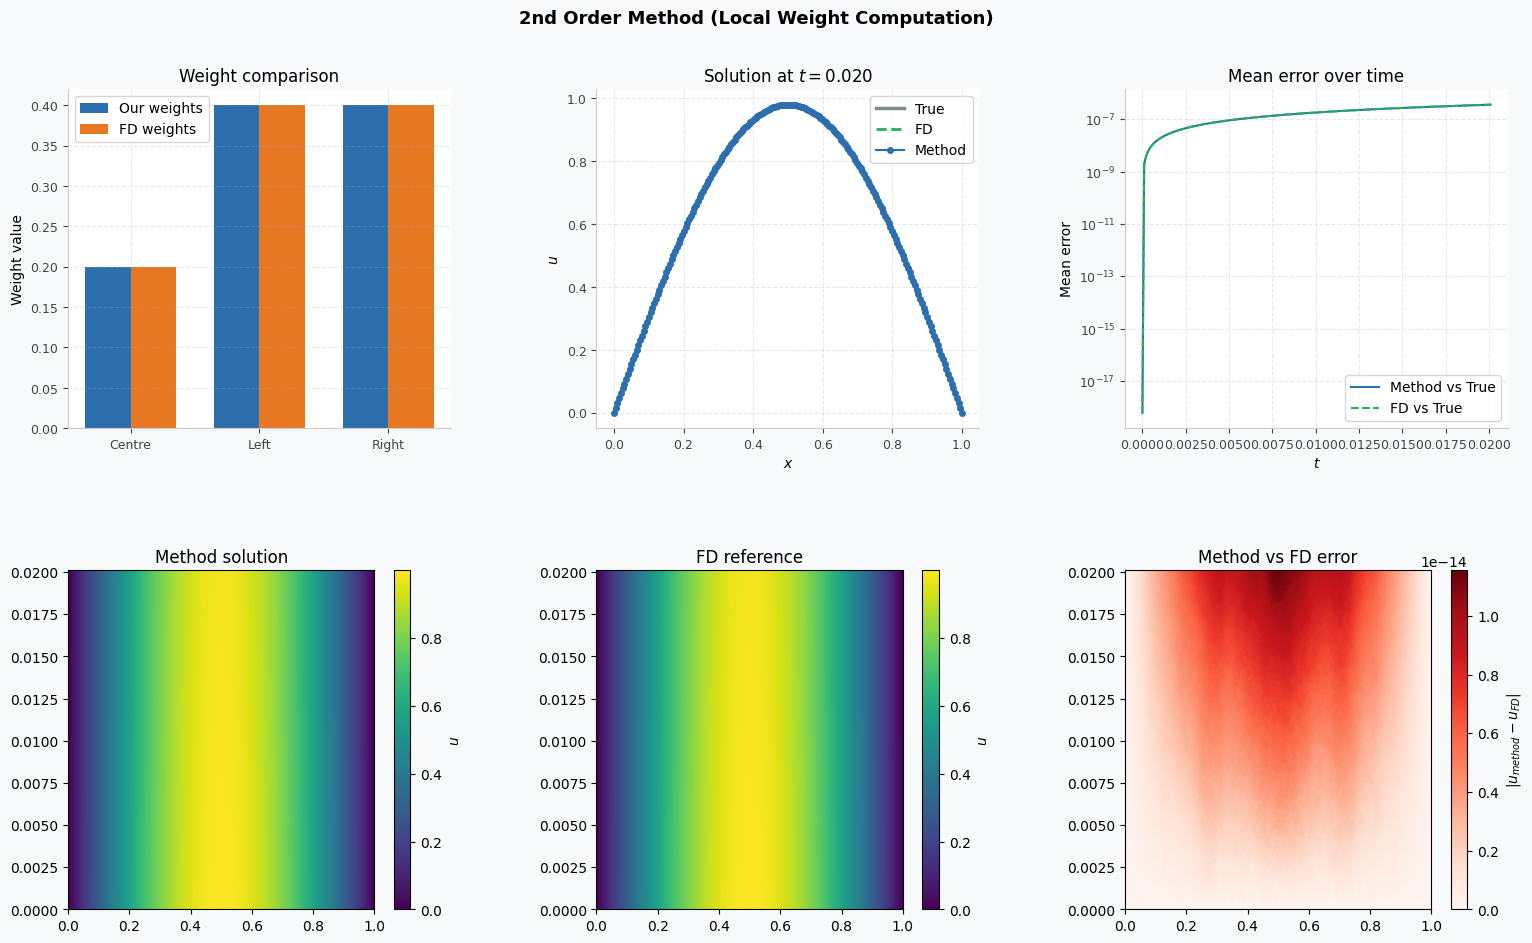

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx = 200
nt = 200

x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

# CFL
r = 0.4
dt = r * dx**2 / alpha

t = np.linspace(0, dt*(nt-1), nt)
T = t[-1]

print(f"dx = {dx:.4f},  dt = {dt:.6f},  CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")
print(f"T  = {T:.4f}")


# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha*np.pi**2*t) * np.sin(np.pi*x)


# --------------------------------------------------
# FD reference solution (explicit Euler)
# --------------------------------------------------
U_fd = np.zeros((nt, nx))

U_fd[0, :] = u_true(x, 0)
U_fd[:, 0] = 0.0
U_fd[:, -1] = 0.0

for k in range(nt-1):

    U_fd[k+1,1:-1] = (
        U_fd[k,1:-1]
        + r*(U_fd[k,2:] - 2*U_fd[k,1:-1] + U_fd[k,:-2])
    )


# --------------------------------------------------
# Local weight solver
# --------------------------------------------------
def compute_weights_grid(dx, dt, alpha):

    dx_nb = np.array([0.0, -dx, dx])
    dt_nb = np.array([-dt, -dt, -dt])

    A = np.array([
        [1.0, 1.0, 1.0],
        dx_nb,
        alpha*dt_nb + 0.5*dx_nb**2
    ])

    b = np.array([1.0, 0.0, 0.0])

    w = np.linalg.solve(A, b)

    return w


# --------------------------------------------------
# FD weights (hard-coded formula)
# --------------------------------------------------
w_fd = np.array([
    1 - 2*alpha*dt/dx**2,
    alpha*dt/dx**2,
    alpha*dt/dx**2
])


# --------------------------------------------------
# Demonstrate weight recovery
# --------------------------------------------------
w_test = compute_weights_grid(dx, dt, alpha)

print("\nStep 1: Weight Recovery")

print(f"{'':20s}{'centre':>12}{'left':>12}{'right':>12}")
print(f"{'Our weights':20s}{w_test[0]:12.6f}{w_test[1]:12.6f}{w_test[2]:12.6f}")
print(f"{'FD weights':20s}{w_fd[0]:12.6f}{w_fd[1]:12.6f}{w_fd[2]:12.6f}")
print(f"{'Difference':20s}{w_test[0]-w_fd[0]:12.2e}{w_test[1]-w_fd[1]:12.2e}{w_test[2]-w_fd[2]:12.2e}")


# --------------------------------------------------
# Full rollout (weights computed EVERY update)
# --------------------------------------------------
U_our = np.zeros((nt, nx))

U_our[0,:] = u_true(x,0)
U_our[:,0] = 0.0
U_our[:,-1] = 0.0


for k in range(nt-1):

    for j in range(1, nx-1):

        # compute weights locally
        w = compute_weights_grid(dx, dt, alpha)

        # neighbour values
        u_nb = np.array([
            U_our[k, j],
            U_our[k, j-1],
            U_our[k, j+1]
        ])

        # update
        U_our[k+1, j] = w @ u_nb


# --------------------------------------------------
# Error analysis
# --------------------------------------------------
print("\nStep 2: Full Rollout Error")

X, Tgrid = np.meshgrid(x, t)

U_true = u_true(X, Tgrid)

err_our_vs_true = np.abs(U_our - U_true)
err_fd_vs_true = np.abs(U_fd - U_true)
err_our_vs_fd = np.abs(U_our - U_fd)

print(f"Our vs True  - mean: {err_our_vs_true.mean():.4e}  max: {err_our_vs_true.max():.4e}")
print(f"FD  vs True  - mean: {err_fd_vs_true.mean():.4e}  max: {err_fd_vs_true.max():.4e}")
print(f"Our vs FD    - mean: {err_our_vs_fd.mean():.4e}  max: {err_our_vs_fd.max():.4e}")


# --------------------------------------------------
# Plot results
# --------------------------------------------------
from Plots.plot_fd_results import plot_fd_results

plot_fd_results(
    x=x,
    t=t,
    T=T,
    U_method=U_our,
    U_fd=U_fd,
    u_true=u_true,
    w=w_test,
    w_fd=w_fd,
    title="2nd Order Method (Local Weight Computation)"
)

## Experiment 3 — Weight Recovery: 5-Point Stencil (4th Order)

**Setup:** $u_t = \alpha u_{xx}$ uniform grid.5 neighbours, 5 constraints (consistency + kill $u_x$ + PDE + kill $u_{xxx}$ + kill $u_{xxxx}$).
Didn't add the constraint on $\Delta t$ because all neighbours have the same $\Delta t$,
making $\sum_i w_i \Delta t_i = -\Delta t \sum_i w_i = -\Delta t$ automatically satisfied via consistency.

**Results:**
- Weights match 4th order FD weights to machine precision (diff $\sim 10^{-16}$)
- Reconstruction error vs exact: $2.43 \times 10^{-6}$
- Our method vs FD: $\sim 10^{-16}$ (machine precision)

Recovered weights: $(0,\ \tfrac{8}{15},\ \tfrac{8}{15},\ -\tfrac{1}{30},\ -\tfrac{1}{30})$,
consistent with the classical 4th order explicit stencil.

In [33]:
import numpy as np

# Parameters
alpha = 0.1
nx = 20
nt = 100
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

r = 0.04  # CFL number
dt = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.6f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha * dt / dx**2:.4f}")

# Pick one target point: interior, second time step
# target: (x*, t*) = (x[5], t[1])
j_star = 5
k_star = 1

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget point: x* = {x_star:.4f}, t* = {t_star:.6f}")

# 5 neighbours (all at previous time step k=0)
# n1: centre  (x*,       t* - dt)
# n2: left    (x* - dx,  t* - dt)
# n3: right   (x* + dx,  t* - dt)
# n4: left    (x* - 2dx,  t* - dt)
# n5: right   (x* + 2dx,  t* - dt)
dx_nb = np.array([0.0, -dx, dx, -2*dx, 2*dx])
dt_nb = np.array([-dt, -dt, -dt, -dt, -dt])

print("\nNeighbours (relative offsets):")
print(f"  Centre: dx = {dx_nb[0]:.4f}, dt = {dt_nb[0]:.6f}")
print(f"  Left:   dx = {dx_nb[1]:.4f}, dt = {dt_nb[1]:.6f}")
print(f"  Right:  dx = {dx_nb[2]:.4f}, dt = {dt_nb[2]:.6f}")
print(f"  Left2:  dx = {dx_nb[3]:.4f}, dt = {dt_nb[3]:.6f}")
print(f"  Right2: dx = {dx_nb[4]:.4f}, dt = {dt_nb[4]:.6f}")
# Build 3x3 matrix A and solve
# Row 1: consistency   sum(w) = 1
# Row 2: spatial bias  sum(w*dx) = 0
# Row 3: diffusion     sum(w*(alpha*dt + 0.5*dx^2)) = 0
# Row 4: 4th order spatial accuracy sum(w*dx^4) = 0
# Row 5: 6th order spatial accuracy sum(w*dx^6) = 0
A = np.array([
    np.ones(5),
    dx_nb,
    dx_nb**2,
    dx_nb**3,
    dx_nb**4
])

b = np.array([
    1.0,
    0.0,
    2 * alpha * dt,
    0.0,
    0.0
])

print("\nMatrix A:")
print(A)
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# FD weights (explicit Euler)
# u* = (1 - 2r)*u_c + r*u_l + r*u_r
nu = alpha * dt / dx**2

w_fd = np.array([
    1 - 30*nu/12,
    16*nu/12,
    16*nu/12,
    -nu/12,
    -nu/12
])
print("\nWeight Comparison")
print(f"{'':10s} {'Centre':>12} {'Left':>12} {'Right':>12}")
print(f"{'Our w':10s} {w[0]:>12.8f} {w[1]:>12.8f} {w[2]:>12.8f} {w[3]:>12.8f} {w[4]:>12.8f}")
print(f"{'FD w':10s} {w_fd[0]:>12.8f} {w_fd[1]:>12.8f} {w_fd[2]:>12.8f} {w_fd[3]:>12.8f} {w_fd[4]:>12.8f}")
print(f"{'Diff':10s} {w[0] - w_fd[0]:>12.2e} {w[1] - w_fd[1]:>12.2e} {w[2] - w_fd[2]:>12.2e} {w[3] - w_fd[3]:>12.2e} {w[4] - w_fd[4]:>12.2e}")

# Apply weights to reconstruct u at target
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star, t_star - dt),
    u_true(x_star - dx, t_star - dt),
    u_true(x_star + dx, t_star - dt),
    u_true(x_star - 2*dx, t_star - dt),
    u_true(x_star + 2*dx, t_star - dt)
])

u_pred = w @ u_nb
u_fd = w_fd @ u_nb
u_exact = u_true(x_star, t_star)
print("\n" + "="*55)
print("NEIGHBOUR OFFSETS (relative)")
print("="*55)
print(f"{'Point':<10}{'dx':>12}{'dt':>15}")
print("-"*37)
print(f"{'Centre':<10}{dx_nb[0]:>12.4f}{dt_nb[0]:>15.6f}")
print(f"{'Left':<10}{dx_nb[1]:>12.4f}{dt_nb[1]:>15.6f}")
print(f"{'Right':<10}{dx_nb[2]:>12.4f}{dt_nb[2]:>15.6f}")

print("\n" + "="*70)
print("WEIGHT COMPARISON")
print("="*70)

print(f"{'':<10}{'Centre':>12}{'Left':>12}{'Right':>12}{'Left2':>12}{'Right2':>12}")
print("-"*70)

print(f"{'Our':<10}{w[0]:>12.8f}{w[1]:>12.8f}{w[2]:>12.8f}{w[3]:>12.8f}{w[4]:>12.8f}")
print(f"{'FD':<10}{w_fd[0]:>12.8f}{w_fd[1]:>12.8f}{w_fd[2]:>12.8f}{w_fd[3]:>12.8f}{w_fd[4]:>12.8f}")
print(f"{'Diff':<10}{(w[0]-w_fd[0]):>12.2e}{(w[1]-w_fd[1]):>12.2e}{(w[2]-w_fd[2]):>12.2e}{(w[3]-w_fd[3]):>12.2e}{(w[4]-w_fd[4]):>12.2e}")

print("\n" + "="*55)
print("RECONSTRUCTION AT TARGET")
print("="*55)
print(f"Predicted (our weights) : {u_pred:.8f}")
print(f"Predicted (FD weights)  : {u_fd:.8f}")
print(f"Exact solution          : {u_exact:.8f}")

print("\nErrors")
print("-"*20)
print(f"Our vs Exact            : {abs(u_pred - u_exact):.4e}")
print(f"FD  vs Exact            : {abs(u_fd - u_exact):.4e}")
print(f"Our vs FD               : {abs(u_pred - u_fd):.4e}")
print("="*55)

dx = 0.052632
dt = 0.001108
CFL r = alpha*dt/dx^2 = 0.0400

Target point: x* = 0.2632, t* = 0.001108

Neighbours (relative offsets):
  Centre: dx = 0.0000, dt = -0.001108
  Left:   dx = -0.0526, dt = -0.001108
  Right:  dx = 0.0526, dt = -0.001108
  Left2:  dx = -0.1053, dt = -0.001108
  Right2: dx = 0.1053, dt = -0.001108

Matrix A:
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00]
 [ 0.00000000e+00 -5.26315789e-02  5.26315789e-02 -1.05263158e-01
   1.05263158e-01]
 [ 0.00000000e+00  2.77008310e-03  2.77008310e-03  1.10803324e-02
   1.10803324e-02]
 [ 0.00000000e+00 -1.45793847e-04  1.45793847e-04 -1.16635078e-03
   1.16635078e-03]
 [ 0.00000000e+00  7.67336039e-06  7.67336039e-06  1.22773766e-04
   1.22773766e-04]]

b = [1.00000000e+00 0.00000000e+00 2.21606648e-04 0.00000000e+00
 0.00000000e+00]

Weight Comparison
                 Centre         Left        Right
Our w        0.90000000   0.05333333   0.05333333  -0.00333333  -0.00333333
FD w      

## Experiment 4 — One-Sided 4th Order Boundary Stencils

**Setup:** Same as Experiment 3 but for points near the boundary ($j=1$ and $j=N-2$)
where the symmetric 5-point stencil would reach outside the domain.

**Interior stencil** (symmetric, offsets $-2,-1,0,+1,+2$):

**Left boundary stencil** ($j=1$, offsets $-1,0,+1,+2,+3$):

**Right boundary stencil** ($j=N-2$, offsets $-3,-2,-1,0,+1$):

All three use the same 5 constraints — the stencil is just shifted laterally.
The right stencil weights are the mirror of the left: $w_R = w_L^{\text{reversed}}$.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx    = 40
nt    = 200
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.05
dt    = r * dx**2 / alpha
t     = np.linspace(0, dt * (nt - 1), nt)
T     = t[-1]

print(f"dx = {dx:.6f},  dt = {dt:.8f},  CFL r = {alpha*dt/dx**2:.4f},  T = {T:.4f}")

# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# --------------------------------------------------
# Weight solvers
# --------------------------------------------------
def solve_weights(dx_nb, dt_nb, alpha, order):
    """General weight solver given neighbour offsets and order (2 or 4)."""
    n = len(dx_nb)
    if order == 2:
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
        ])
        b = np.array([1.0, 0.0, 0.0])
    else:  # order == 4
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
            dx_nb**3 / 6,
            dx_nb**4 / 24,
        ])
        b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    return np.linalg.solve(A, b)

def weights_2nd_order(dx, dt, alpha):
    """3 neighbours, 3 constraints - symmetric 2nd order"""
    dx_nb = np.array([0.0, -dx, +dx])
    dt_nb = np.array([-dt, -dt, -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=2)

def weights_4th_order(dx, dt, alpha):
    """5 neighbours, 5 constraints - symmetric 4th order (interior)"""
    dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
    dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_left(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=1 (near left boundary).
    Neighbours: j-1, j, j+1, j+2, j+3  (offsets: -dx, 0, +dx, +2dx, +3dx)"""
    dx_nb = np.array([-dx,  0.0, +dx, +2*dx, +3*dx])
    dt_nb = np.array([-dt,  -dt, -dt,   -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_right(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=nx-2 (near right boundary).
    Neighbours: j-3, j-2, j-1, j, j+1  (offsets: -3dx, -2dx, -dx, 0, +dx)"""
    dx_nb = np.array([-3*dx, -2*dx, -dx, 0.0, +dx])
    dt_nb = np.array([  -dt,   -dt, -dt, -dt,  -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

# compute weights once (same for all points at fixed dx, dt)
w2     = weights_2nd_order(dx, dt, alpha)
w4     = weights_4th_order(dx, dt, alpha)
w4_L   = weights_4th_order_left(dx, dt, alpha)
w4_R   = weights_4th_order_right(dx, dt, alpha)

# theoretical FD weights
w2_fd = np.array([1 - 2*r, r, r])
w4_fd = np.array([1 - 5*r/2, 4*r/3, 4*r/3, -r/12, -r/12])

print(f"\n--- 2nd order weight check --------------------------------")
print(f"Our:  {w2}")
print(f"FD:   {w2_fd}")
print(f"Diff: {w2 - w2_fd}")

print(f"\n--- 4th order weight check (interior) ---------------------")
print(f"Our:  {w4}")
print(f"FD:   {w4_fd}")
print(f"Diff: {w4 - w4_fd}")

print(f"\n--- 4th order one-sided weights ---------------------------")
print(f"Left  (j=1,   offsets -1,0,+1,+2,+3): {w4_L}")
print(f"Right (j=N-2, offsets -3,-2,-1,0,+1): {w4_R}")
print(f"Are they mirrors? {np.allclose(w4_L, w4_R[::-1])}")

dx = 0.025641,  dt = 0.00032873,  CFL r = 0.0500,  T = 0.0654

--- 2nd order weight check --------------------------------
Our:  [0.9  0.05 0.05]
FD:   [0.9  0.05 0.05]
Diff: [-1.11022302e-16  6.93889390e-18  6.93889390e-18]

--- 4th order weight check (interior) ---------------------
Our:  [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
FD:   [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
Diff: [ 0.00000000e+00  2.77555756e-17  2.77555756e-17  0.00000000e+00
 -1.73472348e-18]

--- 4th order one-sided weights ---------------------------
Left  (j=1,   offsets -1,0,+1,+2,+3): [ 0.04583333  0.91666667  0.025       0.01666667 -0.00416667]
Right (j=N-2, offsets -3,-2,-1,0,+1): [-0.00416667  0.01666667  0.025       0.91666667  0.04583333]
Are they mirrors? True


## Experiment 4 — Results: 2nd vs 4th Order Full Rollout


dx = 0.0050, dt = 0.000051, CFL r = 0.2000
T = 0.1010

Interior weights:
[-0.01666667  0.26666667  0.5         0.26666667 -0.01666667]

Error analysis
Our vs True  mean: 7.3615e-07 max: 2.2477e-06
FD vs True   mean: 7.3615e-07 max: 2.2477e-06
Our vs FD    mean: 5.5832e-14 max: 1.7963e-13


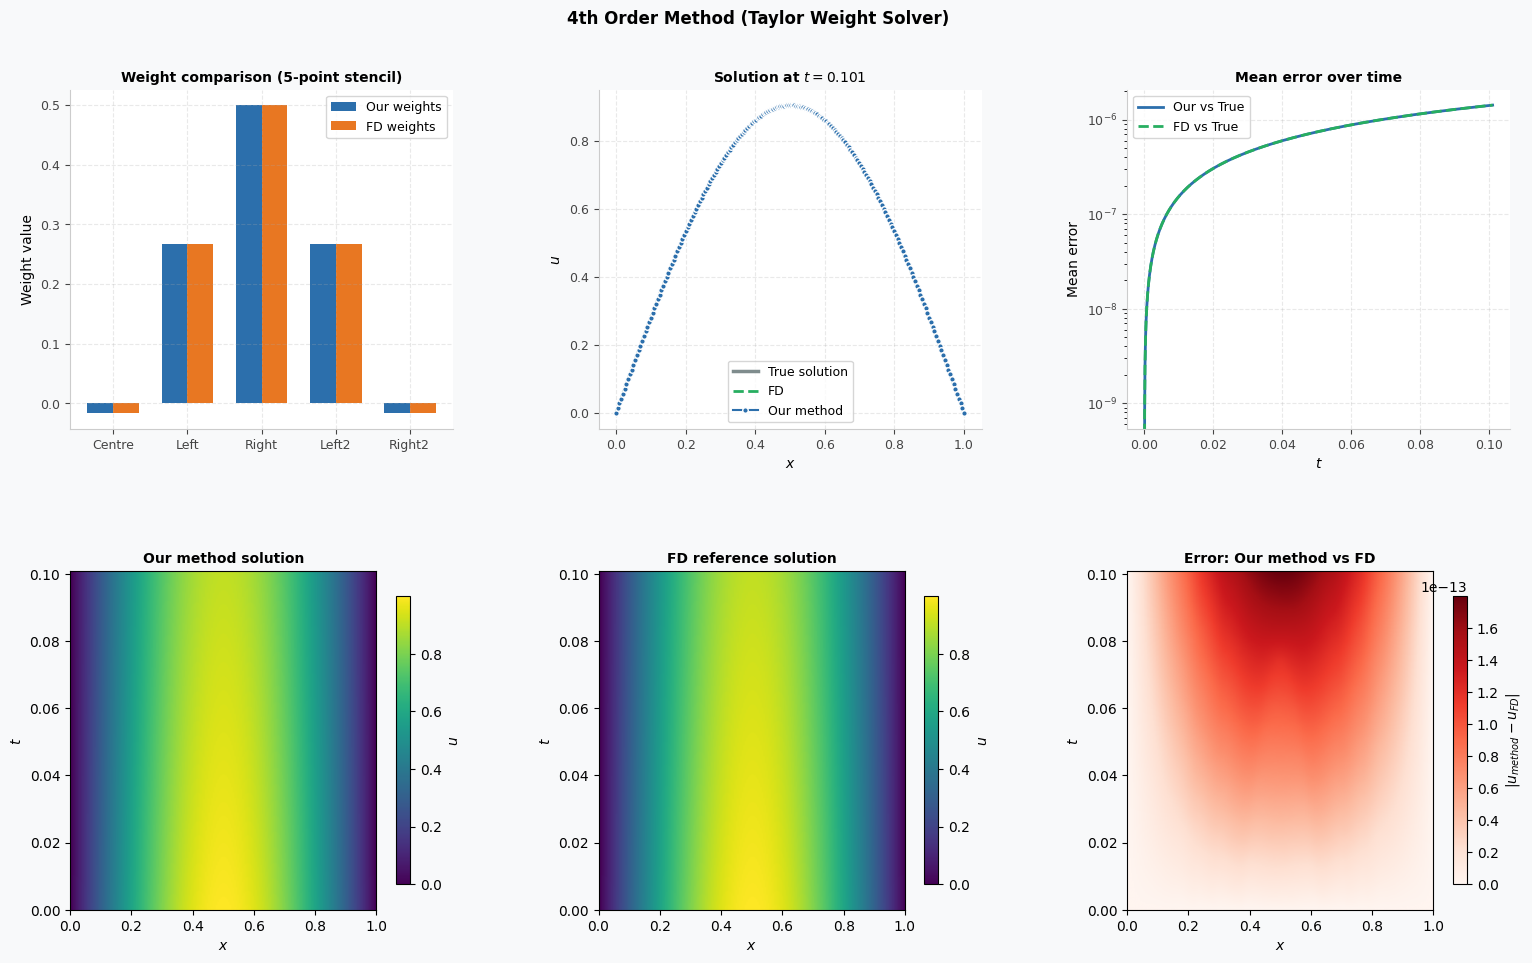

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx = 200
nt = 2000

x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

# CFL
r = 0.2
dt = r * dx**2 / alpha

t = np.linspace(0, dt*(nt-1), nt)
T = t[-1]

print(f"dx = {dx:.4f}, dt = {dt:.6f}, CFL r = {alpha*dt/dx**2:.4f}")
print(f"T = {T:.4f}")

# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x,t):
    return np.exp(-alpha*np.pi**2*t)*np.sin(np.pi*x)

# --------------------------------------------------
# Taylor weight solver
# --------------------------------------------------
def compute_weights(offsets, dx, dt, alpha):

    dx_nb = offsets * dx

    A = np.array([
        np.ones(len(offsets)),
        dx_nb,
        dx_nb**2,
        dx_nb**3,
        dx_nb**4
    ])

    b = np.array([
        1,
        0,
        2*alpha*dt,
        0,
        0
    ])

    return np.linalg.solve(A,b)

# --------------------------------------------------
# Define stencil geometries
# --------------------------------------------------
offset_interior = np.array([-2,-1,0,1,2])
offset_left = np.array([-1,0,1,2,3])
offset_right = np.array([-3,-2,-1,0,1])

# compute weights
w_interior = compute_weights(offset_interior,dx,dt,alpha)
w_left = compute_weights(offset_left,dx,dt,alpha)
w_right = compute_weights(offset_right,dx,dt,alpha)

print("\nInterior weights:")
print(w_interior)

# --------------------------------------------------
# FD reference solution (4th order)
# --------------------------------------------------
U_fd = np.zeros((nt,nx))

U_fd[0,:] = u_true(x,0)

nu = alpha*dt/dx**2

for k in range(nt-1):

    U_fd[k+1,0] = 0
    U_fd[k+1,-1] = 0

    # near boundaries
    # left near boundary
    j = 1
    vals = np.array([U_fd[k, j+i] for i in offset_left])
    U_fd[k+1, j] = w_left @ vals

    # interior
    U_fd[k+1, 2:-2] = (
        U_fd[k, 2:-2]
        + nu/12 * (
            -U_fd[k, 4:]
            + 16*U_fd[k, 3:-1]
            - 30*U_fd[k, 2:-2]
            + 16*U_fd[k, 1:-3]
            - U_fd[k, :-4]
        )
    )

    # right near boundary
    j = nx - 2
    vals = np.array([U_fd[k, j+i] for i in offset_right])
    U_fd[k+1, j] = w_right @ vals

# --------------------------------------------------
# Our method rollout
# --------------------------------------------------
U_our = np.zeros((nt,nx))
U_our[0,:] = u_true(x,0)

for k in range(nt-1):

    U_our[k+1,0] = 0
    U_our[k+1,-1] = 0

    # left one-sided
    j = 1
    vals = np.array([U_our[k,j+i] for i in offset_left])
    U_our[k+1,j] = w_left @ vals

    # interior stencil
    for j in range(2,nx-2):

        vals = np.array([U_our[k,j+i] for i in offset_interior])
        U_our[k+1,j] = w_interior @ vals

    # right one-sided
    j = nx-2
    vals = np.array([U_our[k,j+i] for i in offset_right])
    U_our[k+1,j] = w_right @ vals

# --------------------------------------------------
# Error analysis
# --------------------------------------------------
print("\nError analysis")

X,Tgrid = np.meshgrid(x,t)
U_true = u_true(X,Tgrid)

err_our_vs_true = np.abs(U_our-U_true)
err_fd_vs_true = np.abs(U_fd-U_true)
err_our_vs_fd = np.abs(U_our-U_fd)

print(f"Our vs True  mean: {err_our_vs_true.mean():.4e} max: {err_our_vs_true.max():.4e}")
print(f"FD vs True   mean: {err_fd_vs_true.mean():.4e} max: {err_fd_vs_true.max():.4e}")
print(f"Our vs FD    mean: {err_our_vs_fd.mean():.4e} max: {err_our_vs_fd.max():.4e}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
from Plots.plot_fd_results import plot_fd_results

plot_fd_results(
    x=x,
    t=t,
    T=T,
    U_method=U_our,
    U_fd=U_fd,
    u_true=u_true,
    w=w_interior,
    w_fd=w_interior,
    title="4th Order Method (Taylor Weight Solver)"
)